In [1]:
import pandas as pd

In [2]:
df_fecha=pd.read_excel('Reels_23-3.xlsx')
df_lab=pd.read_excel('calidad_23-3.xlsx')

In [3]:
df_fecha.columns=['NO_REEL', 'FECHA']

In [5]:
df_lab.merge(df_fecha,on='NO_REEL',how='left').to_excel('data_lab_23-3.xlsx',index=False)

# UNIFICAR BASES PHD Y LAB


In [8]:
data_lab=pd.read_excel('data_lab_23-3.xlsx')
data_phd=pd.read_excel('sensor_23-3.xlsx')

In [14]:
data_phd.columns=['FECHA','ASH_VIRTUAL_SENSOR']

In [25]:
data_lab['FECHA']=pd.to_datetime(data_lab['FECHA']).dt.floor('min')

In [26]:
data_phd.merge(data_lab,on='FECHA',how='left').to_excel('data_final_28-3.xlsx',index=False)

In [27]:
df=data_phd.merge(data_lab,on='FECHA',how='left')

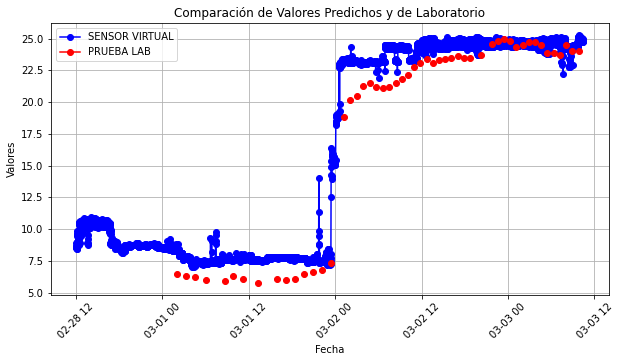

In [31]:
import matplotlib.pyplot as plt

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(df['FECHA'], df['ASH_VIRTUAL_SENSOR'], label='SENSOR VIRTUAL', marker='o', linestyle='-', color='blue')
plt.plot(df['FECHA'], df['VALOR_PRUEBA'], label='PRUEBA LAB', marker='o', linestyle='-', color='red')
 
# Configurar etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Valores')
plt.title('Comparación de Valores Predichos y de Laboratorio')
plt.xticks(rotation=45)  # Rotar las etiquetas del eje X para mejor visualización
plt.legend()  # Mostrar la leyenda
plt.grid()
 
# Mostrar la gráfica
plt.show()

In [ ]:
dates=list(data_lab['FECHA'])

In [ ]:
data_phd.insert(data_phd.shape[1],'CENIZAS',value='')

In [49]:
for date in reversed(dates):
    print(date)
    aux=None
    
    aux=data_lab.loc[data_lab['FECHA']==date,'VALOR_PRUEBA'].values[0]
    print(aux)
    data_phd.loc[data_phd['Timestamp']<=date,'CENIZAS']=aux

2025-02-25 12:39:38
8.5
2025-02-25 11:27:46.800000
8.6
2025-02-25 07:38:07.800000
19.7
2025-02-25 06:00:19.800000
21.5
2025-02-25 05:08:34.800000
23.6
2025-02-25 04:16:13.800000
24.2
2025-02-25 02:21:19.800000
nan
2025-02-24 22:28:22.800000
24.8
2025-02-24 21:44:25.800000
24.7
2025-02-24 20:49:31.800000
24.8
2025-02-24 20:12:19.800000
25.9
2025-02-24 19:17:43.800000
25.8
2025-02-24 18:23:43.800000
26.0
2025-02-24 17:12:28.800000
26.1
2025-02-24 16:30:28.800000
26.5
2025-02-24 15:42:19.800000
26.2
2025-02-24 14:52:40.800000
28.0
2025-02-24 13:54:37.800000
27.2
2025-02-24 03:47:52.800000
25.6
2025-02-24 01:51:19.800000
25.9
2025-02-24 00:55:31.800000
25.8
2025-02-23 20:49:40.800000
24.5
2025-02-23 19:57:19.800000
24.3
2025-02-23 19:05:07.800000
24.5
2025-02-23 18:12:37.800000
24.0
2025-02-23 16:47:16.800000
22.5
2025-02-23 15:03:46.800000
25.0
2025-02-23 14:11:25.800000
24.8
2025-02-23 13:28:04.800000
24.5
2025-02-23 12:49:31.800000
23.9
2025-02-23 11:55:58.800000
23.0
2025-02-23 10:54:3

In [51]:
data_phd.to_excel('data_train.xlsx',index=False)